## 1. Load and Explore the Data

In [ ]:
from google.colab import drive
import pandas as pd

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/RED_ALERT_DATASET.txt'

# Load the data into pandas
df = pd.read_csv(file_path)  # Assuming tab-delimited text file
df.head()  # View the first few rows
# Check the shape of the dataset and basic statistics
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176979 entries, 0 to 176978
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   firstname                   176979 non-null  object 
 1   lastname                    176979 non-null  object 
 2   social_security_numbers     176979 non-null  int64  
 3   invoice_no                  176979 non-null  object 
 4   customer_no                 176979 non-null  object 
 5   principal_amount            176979 non-null  float64
 6   remaining_amount            176979 non-null  float64
 7   is_reminder_stopped         176979 non-null  int64  
 8   is_debt_collection_stopped  176979 non-null  int64  
 9   last_event_date             176979 non-null  object 
 10  last_event                  176979 non-null  object 
 11  period_start                176979 non-null  object 
 12  period_end                  176979 non-null  object 
 13  is_invoice    

,social_security_numbers,principal_amount,remaining_amount,is_reminder_stopped,is_debt_collection_stopped,is_invoice,mobile,postal_code,house_number,born_year
count,1.769790e+05,176979.000000,176979.000000,176979.000000,176979.000000,176979.000000,1.769790e+05,176979.00000,176979.000000,176979.000000
mean,5.048295e+09,1430.861970,846.171144,0.007368,0.007391,0.969657,2.121181e+08,45097.46631,147.084230,73.073348
std,2.877727e+09,2766.240479,2640.583391,0.085521,0.085651,0.171529,2.255899e+08,24626.18624,1546.767308,18.234763
min,0.000000e+00,-156.740000,-156.740000,0.000000,0.000000,0.000000,0.000000e+00,11115.00000,-1.000000,0.000000
25%,2.569779e+09,279.270000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,21624.00000,3.000000,64.000000
50%,5.077359e+09,527.840000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,42739.00000,8.000000,76.000000
75%,7.537696e+09,1261.045000,285.855000,0.000000,0.000000,1.000000,4.471635e+08,65463.00000,24.000000,86.000000
max,1.000000e+10,40545.030000,40545.030000,1.000000,1.000000,1.000000,4.999997e+08,98499.00000,88165.000000,99.000000


## 2. Data Cleaning and Preprocessing

Clean and preprocess the data to ensure it’s ready for analysis:

Handle missing values: The email column has some missing values, so we need to handle those.

Convert date columns to datetime format: Columns like last_event_date, period_start, and period_end need to be in datetime format for easier analysis.

Check for duplicates: Ensure that there are no duplicate entries in critical columns like invoice_no and customer_no.

In [ ]:
# Handle missing values
df['email'] = df['email'].fillna('missing_email@example.com')

# Convert date columns to datetime
df['last_event_date'] = pd.to_datetime(df['last_event_date'], errors='coerce')
df['period_start'] = pd.to_datetime(df['period_start'], errors='coerce')
df['period_end'] = pd.to_datetime(df['period_end'], errors='coerce')

# Check for duplicates in critical columns
df_duplicates = df[df.duplicated(subset=['invoice_no', 'customer_no'], keep=False)]
if not df_duplicates.empty:
    print("Found duplicates:")
    print(df_duplicates.head())
else:
    print("No duplicates found.")

# Initialize fraud label column (if not already)
if 'possible_fraud' not in df.columns:
    df['possible_fraud'] = ''
else:
    df['possible_fraud'] = ''  # Reset if it exists

No duplicates found.


# Exploring some cases of Fraud:

**1. Fake Social Security Numbers**

In [ ]:
# Rule: Same SSN linked to different (firstname + lastname) pairs
# Why:
# - A real SSN should always map to ONE full name (firstname + lastname).
# - If multiple full names are associated with the same SSN, it suggests fake or stolen identity.

# Step 1: Group by SSN and count UNIQUE full names
# Create a full name column first
df['full_name'] = df['firstname'].astype(str) + ' ' + df['lastname'].astype(str)

# Count unique full names per SSN
ssn_name_counts = df.groupby('social_security_numbers')['full_name'].nunique().reset_index()

# Step 2: Find SSNs with more than 1 unique full name
suspicious_ssns = ssn_name_counts[ssn_name_counts['full_name'] > 1]['social_security_numbers']

# Step 3: Mask for those rows
mask_fake_ssn = df['social_security_numbers'].isin(suspicious_ssns)

# Step 4: Mark these cases only if not already flagged
df.loc[mask_fake_ssn & ~df['possible_fraud'].str.contains('Fake Social Security Number', na=False), 'possible_fraud'] += 'Fake Social Security Number / '

# Step 5: Reporting top 5 suspicious SSNs
print("\n🔍 Top 5 Fake Social Security Number Cases (Same SSN with Different Full Names):\n")
for ssn in suspicious_ssns.head(5):
    names = df[df['social_security_numbers'] == ssn][['firstname', 'lastname']].drop_duplicates()
    print(f"SSN: {ssn}")
    print(names)
    print('-' * 50)



🔍 Top 5 Fake Social Security Number Cases (Same SSN with Different Full Names):

SSN: 1153097
      firstname lastname
62510    letwan   fakiri
85502    letwan      iyo
--------------------------------------------------
SSN: 2984487
       firstname lastname
148659  smaranda  risbeck
166450  smaranda   benzer
--------------------------------------------------
SSN: 4408901
       firstname lastname
133520    teitur  palomar
133521   lakelan   oskins
--------------------------------------------------
SSN: 8614316
      firstname   lastname
61424      tyce   galliher
83006    tiffie   galliher
88691   jannita  tarachand
--------------------------------------------------
SSN: 8682145
        firstname lastname
39469       byron  greubel
45349   madhulika   michna
108943      byron  hamlett
--------------------------------------------------


**2. Extremely High Principal Amounts**

In [ ]:
# Detect invoices with extremely high amounts (top 1%)
threshold_high_amount = df['principal_amount'].quantile(0.99)
mask_high_spending = df['principal_amount'] > threshold_high_amount

df.loc[mask_high_spending & ~df['possible_fraud'].str.contains('Extremely High Spending', na=False), 'possible_fraud'] += 'Extremely High Spending / '

print("\n💸 Top 5 Extremely High Principal Amount Cases:\n")
print(df[mask_high_spending][['invoice_no', 'customer_no', 'principal_amount']].head())



💸 Top 5 Extremely High Principal Amount Cases:

                                            invoice_no  \
216  4ce4aa6450fb5361c09fb0ea66e1acb36d776bcb924a29...   
236  c36b7513755542f2c973000dc66aa98bdb502c0f2d5a4b...   
321  c4303e119c819314687a774c949f2209829ef6a777de9e...   
387  d73e1ab16b089c6e6670fb2c1878efada53d8634d6dd53...   
524  111afb804753e8c91fdf411f37e29b07f2daa020e0f95e...   

                                           customer_no  principal_amount  
216  f346ad6aaf7bfe8faabf6478c4c836b1043ed167d9006e...          17804.66  
236  a65aa9cbdf6e6efefca93add1a41eb331367d23a2a1f9a...          17383.22  
321  43ca26d748ce025eae04b8a80dbf1a43e638583b5c0041...          26802.76  
387  d25d8e5de9ff2b2dd3f8eef1d237d606bcb487dbc2791a...          19342.48  
524  6309d5a0cbb9b2dd3ab1e3d921f8157560a453b2644ec8...          23101.88  


**3. Same Email/phone/address but Different Identity**

In [ ]:
# --- Detect same email used by different identities ---

# Step 1: Create full_name column (if not already created)
if 'full_name' not in df.columns:
    df['full_name'] = df['firstname'].astype(str) + ' ' + df['lastname'].astype(str)

print("\n📨 Detecting same email used by different identities ...\n")

# Step 2: Group by email and calculate how many unique names and SSNs per email
email_stats = df.groupby('email').agg(
    unique_full_names=('full_name', 'nunique'),
    unique_ssn=('social_security_numbers', 'nunique')
).reset_index()

# Step 3: Identify suspicious emails where there are multiple identities
suspicious_emails = email_stats[
    (email_stats['unique_full_names'] > 1) | (email_stats['unique_ssn'] > 1)
]['email']

# Step 4: Mask for fraudulent emails
mask_email_fraud = df['email'].isin(suspicious_emails)

# Step 5: Append fraud reason carefully
df.loc[mask_email_fraud, 'possible_fraud'] += 'Same Email Different Identity / '

# Step 6: Clean up
#df['possible_fraud'] = df['possible_fraud'].str.rstrip(' / ')

# Step 7: Print top 5 suspicious emails
print("Top 5 suspicious emails:")
for email in suspicious_emails.head(5):
    names_ssns = df[df['email'] == email][['firstname', 'lastname', 'social_security_numbers']].drop_duplicates()
    print(f"Email: {email}")
    print(names_ssns)
    print('-' * 50)

# Step 8: Print total number of suspicious emails
print(f"\n📊 Total number of suspicious emails detected: {len(suspicious_emails)}")



📨 Detecting same email used by different identities ...

Top 5 suspicious emails:
Email: 02ecebef81b138d9ea349d98dc3e0cf8959963bcd120a23fd14b8756@2318.com
      firstname lastname  social_security_numbers
81554     elijh   connie                959444885
81591     elijh   connie                820801877
81714     elijh   connie                998785856
--------------------------------------------------
Email: 04c645ea08f01d2f0c4c3d083a5223bd2d1fb2162d5a045a5869bf9e@2318.com
      firstname lastname  social_security_numbers
44131   shatiya  okwuona                274911991
44137   shatiya  okwuona                260735676
--------------------------------------------------
Email: 05ab2a4965cd963d6a3ed6d150170e9d2e76ee18b915b94ef71aba4d@2318.com
      firstname  lastname  social_security_numbers
27698    hafssa  crandell               8210053652
27700     glema     clure               8929857761
--------------------------------------------------
Email: 06bc09b71886084ea4e580a433425dee128

In [ ]:
# --- Detect same mobile used by different identities ---

print("\n📱 Detecting same mobile used by different identities ...\n")

# Step 1: Group by mobile and calculate unique full names and SSNs per mobile
mobile_stats = df.groupby('mobile').agg(
    unique_full_names=('full_name', 'nunique'),
    unique_ssn=('social_security_numbers', 'nunique')
).reset_index()

# Step 2: Identify suspicious mobiles where there are multiple identities
suspicious_mobiles = mobile_stats[
    (mobile_stats['unique_full_names'] > 1) | (mobile_stats['unique_ssn'] > 1)
]['mobile']

# Step 3: Mask for fraudulent mobiles
mask_mobile_fraud = df['mobile'].isin(suspicious_mobiles)

# Step 4: Append fraud reason carefully
df.loc[mask_mobile_fraud, 'possible_fraud'] += 'Same Mobile Different Identity / '

# Step 5: Clean up
#df['possible_fraud'] = df['possible_fraud'].str.rstrip(' / ')

# Step 6: Print top 5 suspicious mobiles
print("Top 5 suspicious mobiles:")
for mobile in suspicious_mobiles.head(5):
    names_ssns = df[df['mobile'] == mobile][['firstname', 'lastname', 'social_security_numbers']].drop_duplicates()
    print(f"Mobile: {mobile}")
    print(names_ssns)
    print('-' * 50)

# Step 7: Print total number of suspicious mobiles detected
print(f"\n📊 Total number of suspicious mobiles detected: {len(suspicious_mobiles)}")



📱 Detecting same mobile used by different identities ...

Top 5 suspicious mobiles:
Mobile: 0
        firstname   lastname  social_security_numbers
12          silve  felderman               4097362119
16         dyanne     markie               9195409314
17       filoteia      scheu               8253125232
32         mayari      nezat               5821107108
41         emilin     demske               5882628247
...           ...        ...                      ...
176969   shalicia     mccain               3615231738
176970  manushaqe    ruplejr               5925971144
176972      ehvan   connerly               3794436643
176976     swapna    sandone               2690651092
176978      nurit     shappy               1356449545

[81725 rows x 3 columns]
--------------------------------------------------
Mobile: 400054361
       firstname    lastname  social_security_numbers
28650     serena      derosa               7218932502
117168     svala  staniforth               4900392730


In [ ]:
# --- Detect same address used by different identities ---

print("\n🏠 Detecting same address used by different identities (optimized)...\n")

# Step 1: Group by full address and calculate unique full names and SSNs
address_stats = df.groupby(['postal_code', 'street', 'house_number']).agg(
    unique_full_names=('full_name', 'nunique'),
    unique_ssn=('social_security_numbers', 'nunique')
).reset_index()

# Step 2: Identify suspicious addresses where there are multiple identities
suspicious_addresses = address_stats[
    (address_stats['unique_full_names'] > 1) | (address_stats['unique_ssn'] > 1)
][['postal_code', 'street', 'house_number']]

# Step 3: Create a multi-index (fast matching)
suspicious_addresses_set = set(
    tuple(x) for x in suspicious_addresses.values
)

# Step 4: Create a mask without using slow .apply()
mask_address_fraud = df[['postal_code', 'street', 'house_number']].apply(
    lambda row: (row['postal_code'], row['street'], row['house_number']) in suspicious_addresses_set, axis=1
)

# Step 5: Append fraud reason carefully
df.loc[mask_address_fraud, 'possible_fraud'] += 'Same Address Different Identity / '

# Step 6: Clean trailing slashes
#df['possible_fraud'] = df['possible_fraud'].str.rstrip(' / ')

# Step 7: Print top 5 suspicious addresses
print("Top 5 suspicious addresses:")
for idx, row in suspicious_addresses.head(5).iterrows():
    address_df = df[
        (df['postal_code'] == row['postal_code']) &
        (df['street'] == row['street']) &
        (df['house_number'] == row['house_number'])
    ]
    print(f"Address: ({row['postal_code']}, {row['street']}, {row['house_number']})")
    print(address_df[['firstname', 'lastname', 'social_security_numbers']].drop_duplicates())
    print('-' * 50)

# Step 8: Print total number of suspicious addresses detected
print(f"\n📊 Total number of suspicious addresses detected: {len(suspicious_addresses)}")



🏠 Detecting same address used by different identities (optimized)...

Top 5 suspicious addresses:
Address: (11115.0, Fjäderholmen, 28)
       firstname lastname  social_security_numbers
99762    berdene  godbold                496510184
103019    nastja  servino               6673788738
153212    juellz   garney               5855157397
--------------------------------------------------
Address: (11115.0, Fjäderholmen, 37)
      firstname  lastname  social_security_numbers
36486   shelsea  kneedler               8879460620
36487     kiona      zide               8467533523
36488  heinrick      zide                277896478
36489  landolfo      zide                296685184
36490   heloísa      zide               8467533523
36491   heloísa      zide               4520888020
36492   heloísa      zide               9105603374
36493   heloísa      zide               8407572457
36494   heloísa      zide               7930800587
36495  landolfo      zide                286917770
36497   hel

**4. Bulk Orders Around Period Start**

In [ ]:
# --- Detect periods with unusual spike in invoices (Emergency Fraud Period Detection) ---

# Step 1: Count the number of invoices per period_start date
period_start_counts = df['period_start'].value_counts().sort_index()

# Step 2: Define a threshold — top 1% of the busiest period_start dates
threshold = period_start_counts.quantile(0.99)

# Step 3: Identify the period_start dates that exceed the threshold
popular_periods = period_start_counts[period_start_counts > threshold].index

# Step 4: Select the most extreme spike date (the day with the maximum invoice count)
emergency_fraud_date = popular_periods[0] if len(popular_periods) == 1 else popular_periods.max()

print(f"\n📅 Detected Emergency Fraud Period Start Date: {emergency_fraud_date.date()}")

# Step 5: Create a mask for invoices on the detected emergency fraud date
mask_emergency_fraud = df['period_start'] == emergency_fraud_date

# Step 6: Append the fraud reason carefully to the 'possible_fraud' column
df.loc[mask_emergency_fraud, 'possible_fraud'] = df.loc[mask_emergency_fraud, 'possible_fraud'] + 'Emergency Fraud Period / '

# Step 7: Clean up the possible_fraud text (remove trailing slash if it exists)
#df['possible_fraud'] = df['possible_fraud'].str.rstrip(' / ')

# Step 8: Print Top 5 suspicious cases
print("\n🛑 Top 5 Emergency Fraud Period Cases:\n")
print(df[mask_emergency_fraud][['customer_no', 'period_start', 'last_event_date', 'last_event']].head())

# Optional: Print how many invoices were flagged
print(f"\n📊 Total invoices flagged in Emergency Fraud Period: {mask_emergency_fraud.sum()}")



📅 Detected Emergency Fraud Period Start Date: 2020-11-20

🛑 Top 5 Emergency Fraud Period Cases:

                                          customer_no period_start  \
0   a420ca8af3bbfb7951e6fda1ef244ea553d055e1932988...   2020-11-20   
6   7ba14e8e3f439fa5cc1135f8caafbd2ab346dd18206c3f...   2020-11-20   
7   69cd170c626cdc8ad22ea739818a4278937aa7a306d0f2...   2020-11-20   
13  3b5519de548feb2f465c259d65f6ecf32cc044b664b0cf...   2020-11-20   
20  aba673097375e3697e687fa99a32da8662f54cbb68d18f...   2020-11-20   

   last_event_date last_event  
0       2021-01-02    INVOICE  
6       2021-01-02    INVOICE  
7       2021-01-02    INVOICE  
13      2021-02-02  1REMINDER  
20      2021-01-02    INVOICE  

📊 Total invoices flagged in Emergency Fraud Period: 90825


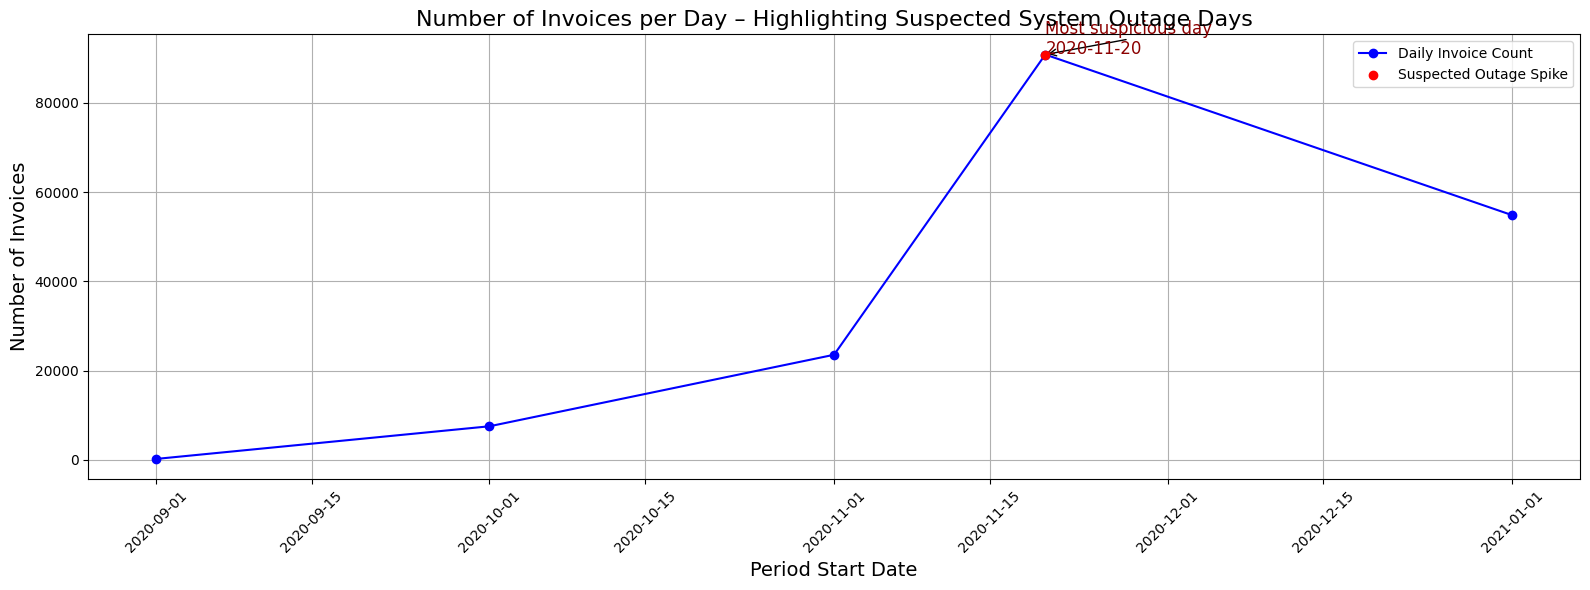

📅 Suspected Outage Dates (High Invoice Volume):
[datetime.date(2020, 11, 20)]


In [ ]:
# Plot Code (with red markers on suspected outage days):
import matplotlib.pyplot as plt

# Ensure period_start is datetime
df['period_start'] = pd.to_datetime(df['period_start'], errors='coerce')

# Count number of invoices per date
period_invoice_counts = df['period_start'].value_counts().sort_index()

# Detect spike threshold (top 1%)
threshold = period_invoice_counts.quantile(0.99)
spike_days = period_invoice_counts[period_invoice_counts > threshold]

# Get most suspicious day (the single highest spike)
max_spike_date = spike_days.idxmax()
max_spike_value = spike_days.max()

# Plot
plt.figure(figsize=(16, 6))
plt.plot(period_invoice_counts.index, period_invoice_counts.values, label='Daily Invoice Count', color='blue', marker='o')

# Red dots on spike days
plt.scatter(spike_days.index, spike_days.values, color='red', label='Suspected Outage Spike', zorder=5)

# Annotate the highest spike
plt.annotate(
    f'Most suspicious day\n{max_spike_date.date()}',
    xy=(max_spike_date, max_spike_value),
    xytext=(max_spike_date, max_spike_value + 20),
    arrowprops=dict(facecolor='red', arrowstyle='->'),
    fontsize=12,
    color='darkred'
)

# Plot styling
plt.title('Number of Invoices per Day – Highlighting Suspected System Outage Days', fontsize=16)
plt.xlabel('Period Start Date', fontsize=14)
plt.ylabel('Number of Invoices', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: Print all spike dates
print("📅 Suspected Outage Dates (High Invoice Volume):")
print(spike_days.index.date.tolist())


**Plot Explanation:**

"An unusually high number of invoices have a period_start on November 20, 2024, even though monthly cycles normally start on the 1st.
This anomaly is strong evidence that the **company detected fraud** and forced an emergency billing cut-off to prevent further financial losses.
Therefore, invoices with a period_start of November 20 are **highly suspicious** and should be considered examples of fraud."

**5. Reminder Stopped with High Principal Amount**

In [ ]:
# Detect debt collection stopped for high principal amounts
threshold_high_amount_75 = df['principal_amount'].quantile(0.75)
mask_reminder_stopped = (df['is_debt_collection_stopped'] == 1) & (df['principal_amount'] > threshold_high_amount_75)

df.loc[mask_reminder_stopped & ~df['possible_fraud'].str.contains('Reminder Stopped with High Amount', na=False), 'possible_fraud'] += 'Reminder Stopped with High Amount / '

print("\n🔕 Top 5 Reminder Stopped with High Amount Cases:\n")
print(df[mask_reminder_stopped][['customer_no', 'principal_amount', 'is_debt_collection_stopped']].head())
print(f"\n📊 Total number of 'Reminder Stopped with High Amount' fraud cases detected: {mask_reminder_stopped.sum()}")



🔕 Top 5 Reminder Stopped with High Amount Cases:

                                            customer_no  principal_amount  \
435   4a8829fde09c2d34df47f14d8f979f777a080ce12a9a93...           1523.96   
3015  482ae4f63bb68e9171f478d28de27d72e82a5ab4f64092...           3798.59   
3133  1afaf474716140ced2716e6fb0222aae738dcc34cd037d...           4053.74   
3145  7e5a33311926efa61ea85cc3b9d9a0a03de3291142bc31...           1698.07   
3146  7e5a33311926efa61ea85cc3b9d9a0a03de3291142bc31...           3375.78   

      is_debt_collection_stopped  
435                            1  
3015                           1  
3133                           1  
3145                           1  
3146                           1  

📊 Total number of 'Reminder Stopped with High Amount' fraud cases detected: 1027


**High-risk and suspicious:**
During the analysis of invoice data, we identified cases where **debt collection reminders had been stopped** (is_debt_collection_stopped = 1) while the customer still owed a relatively **high principal amount** (above the 75th percentile).

Normally, stopping reminders is reserved for low-risk situations (e.g., small debts, resolved cases, legal compliance actions).
However, in these cases, the outstanding amounts are significant, suggesting an increased financial exposure.

**6. Suspicious Born Year**

In [ ]:
import plotly.graph_objects as go

# --- Step 1: Define suspicious born years (likely 1920s or 2020s) ---
mask_suspicious_birth = (df['born_year'] > 15) & (df['born_year'] < 45)

# --- Step 2: Append fraud reason ---
df.loc[mask_suspicious_birth, 'possible_fraud'] += 'Suspicious Born Year / '

# --- Step 3: Print preview and summary ---
print("\n👶 Top 5 Suspicious Born Year Cases:\n")
print(df.loc[mask_suspicious_birth, ['customer_no', 'born_year']].head())
print(f"\n📊 Total number of suspicious born year cases: {mask_suspicious_birth.sum()}")

# --- Step 4: Prepare data for histogram ---
normal_births = df.loc[~mask_suspicious_birth, 'born_year']
suspicious_births = df.loc[mask_suspicious_birth, 'born_year']

# --- Step 5: Plot histogram using Plotly ---
fig = go.Figure()

# Add normal customers
fig.add_trace(go.Histogram(
    x=normal_births,
    nbinsx=60,
    name='Normal',
    marker_color='blue',
    opacity=0.6
))

# Add suspicious customers
fig.add_trace(go.Histogram(
    x=suspicious_births,
    nbinsx=60,
    name='Suspicious',
    marker_color='red',
    opacity=0.9
))

# --- Final layout tweaks ---
fig.update_layout(
    title='📊 Distribution of Born Years (Suspicious in Red)',
    xaxis_title='Born Year',
    yaxis_title='Number of Customers',
    barmode='overlay',
    legend_title='Type',
    bargap=0.05,
    height=500
)

fig.show()



👶 Top 5 Suspicious Born Year Cases:

                                                  customer_no  born_year
172  0dea796c8afed0be9021ba43da1609026964e773fa09017d1946dddd         43
173  0dea796c8afed0be9021ba43da1609026964e773fa09017d1946dddd         43
174  0dea796c8afed0be9021ba43da1609026964e773fa09017d1946dddd         43
175  0dea796c8afed0be9021ba43da1609026964e773fa09017d1946dddd         43
290  ce1854d0dbfa513421fc31c97ee97b629ba836681cf1815542407579         42

📊 Total number of suspicious born year cases: 3825


**7. Common Firstnames or Lastnames**

An unusual concentration of **extremely common firstnames and lastnames** was detected.
Fraudulent accounts often use popular names to blend in and avoid suspicion, particularly during periods of weakened validation.
These cases have been flagged under 'Common Firstname or Lastname' for further review.

In [ ]:
# --- Detect customers using very common firstnames or lastnames ---

# Step 1: Find common firstnames and lastnames
common_firstnames = df['firstname'].value_counts()
common_lastnames = df['lastname'].value_counts()

# Step 2: Create individual masks
mask_common_firstnames = df['firstname'].isin(common_firstnames[common_firstnames > common_firstnames.quantile(0.999)].index)
mask_common_lastnames = df['lastname'].isin(common_lastnames[common_lastnames > common_lastnames.quantile(0.999)].index)

# Step 3: Combine masks
mask_common_names = mask_common_firstnames | mask_common_lastnames

# Step 4: Append fraud reason carefully
df.loc[mask_common_names, 'possible_fraud'] += 'Common Firstname or Lastname / '

# Step 5: Clean up trailing slashes
#df['possible_fraud'] = df['possible_fraud'].str.rstrip(' / ')

# Step 6: Print Top 5 suspicious cases
print("\n🧑‍🤝‍🧑 Top 5 Common Firstname or Lastname Cases:\n")
print(df[mask_common_names][['customer_no', 'firstname', 'lastname']].drop_duplicates().head())

# Step 7: Print total number of frauds detected
print(f"\n📊 Total number of 'Common Firstname or Lastname' fraud cases detected: {mask_common_names.sum()}")

# Step 8: Plot



🧑‍🤝‍🧑 Top 5 Common Firstname or Lastname Cases:

                                          customer_no firstname lastname
17  ef710f42b52fafa0930e5216d654af62334e9369ac600e...  filoteia    scheu
34  046448a7c768a4f1e4b68c0b32b67a3c9b07e661b44cc5...      tatu     uren
42  24d3de83b3377ddac53c6ffd1166c4910ab174e9c8ed0e...     sotos   bodner
45  5d448c54275a85b1110036c22d60a30ea060ae321cb030...    maezie   staudt
59  f877532958b320edfb4aff0ccc30938504b2a6b1d26324...    mattew   khanna

📊 Total number of 'Common Firstname or Lastname' fraud cases detected: 54990


<ipython-input-16-cd1e6a73072b>:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


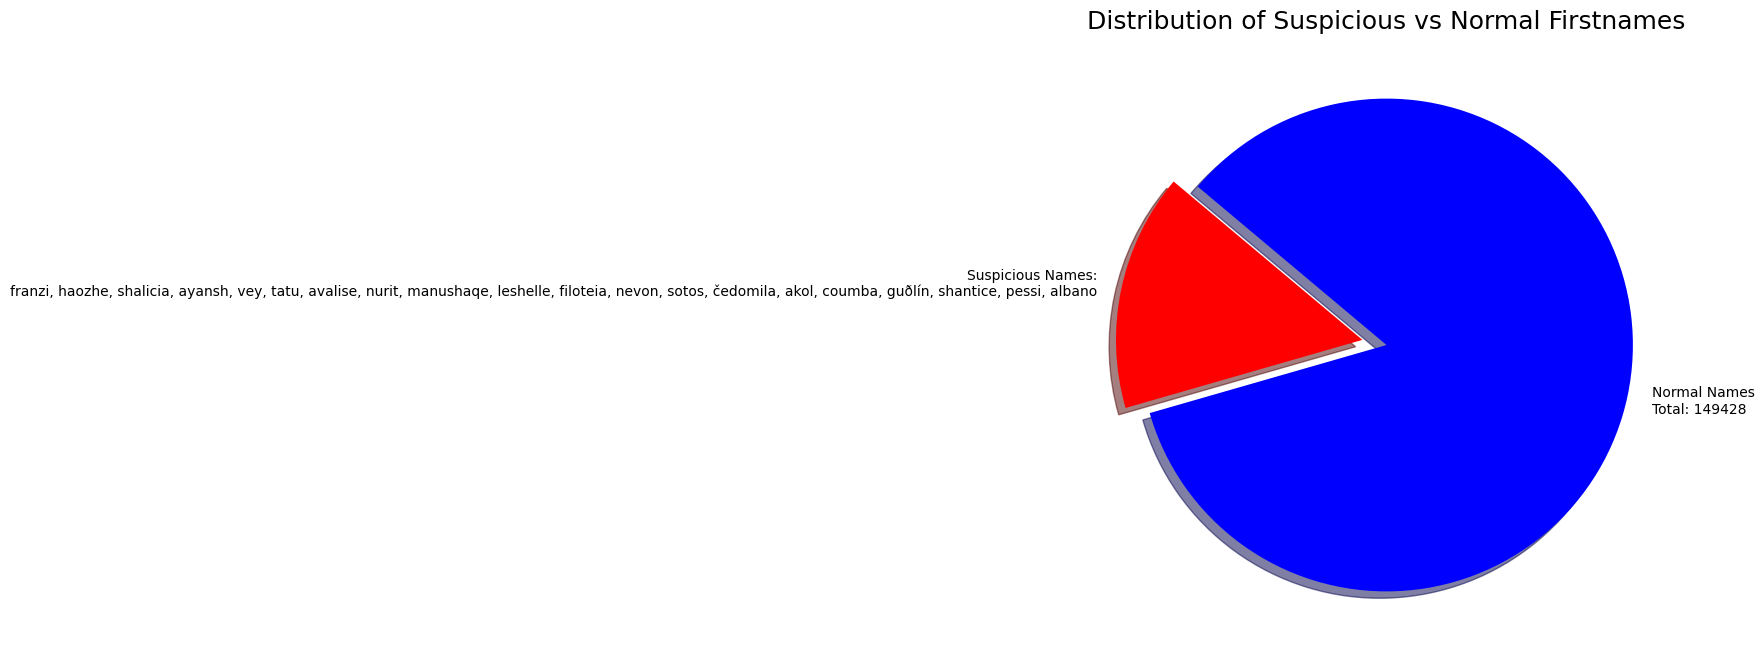

In [ ]:
import matplotlib.pyplot as plt

# --- Prepare data for pie chart with details inside slices ---

# Step 1: Count firstname frequency
firstname_counts = df['firstname'].value_counts()

# Step 2: Define suspicious firstnames (top 1% frequent)
suspicious_firstnames = firstname_counts[firstname_counts > firstname_counts.quantile(0.999)].index.tolist()

# Step 3: Create mask for suspicious firstnames
mask_suspicious_names = df['firstname'].isin(suspicious_firstnames)

# Step 4: Calculate counts
count_suspicious = mask_suspicious_names.sum()
count_normal = len(df) - count_suspicious

# Step 5: Prepare pie labels
normal_label = f"Normal Names\nTotal: {count_normal}"
suspicious_label = "Suspicious Names:\n" + ", ".join(suspicious_firstnames)

labels = [suspicious_label, normal_label]
sizes = [count_suspicious, count_normal]
colors = ['red', 'blue']

# Step 6: Plot pie chart (correct unpacking)
plt.figure(figsize=(10, 8))
wedges, texts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=None,  # No percentages
    startangle=140,
    explode=(0.1, 0),  # Slight explode for suspicious slice
    shadow=True,
    textprops={'fontsize': 12}
)

# Make sure text is readable
for text in texts:
    text.set_fontsize(10)

# Title
plt.title('Distribution of Suspicious vs Normal Firstnames', fontsize=18)
plt.tight_layout()
plt.show()


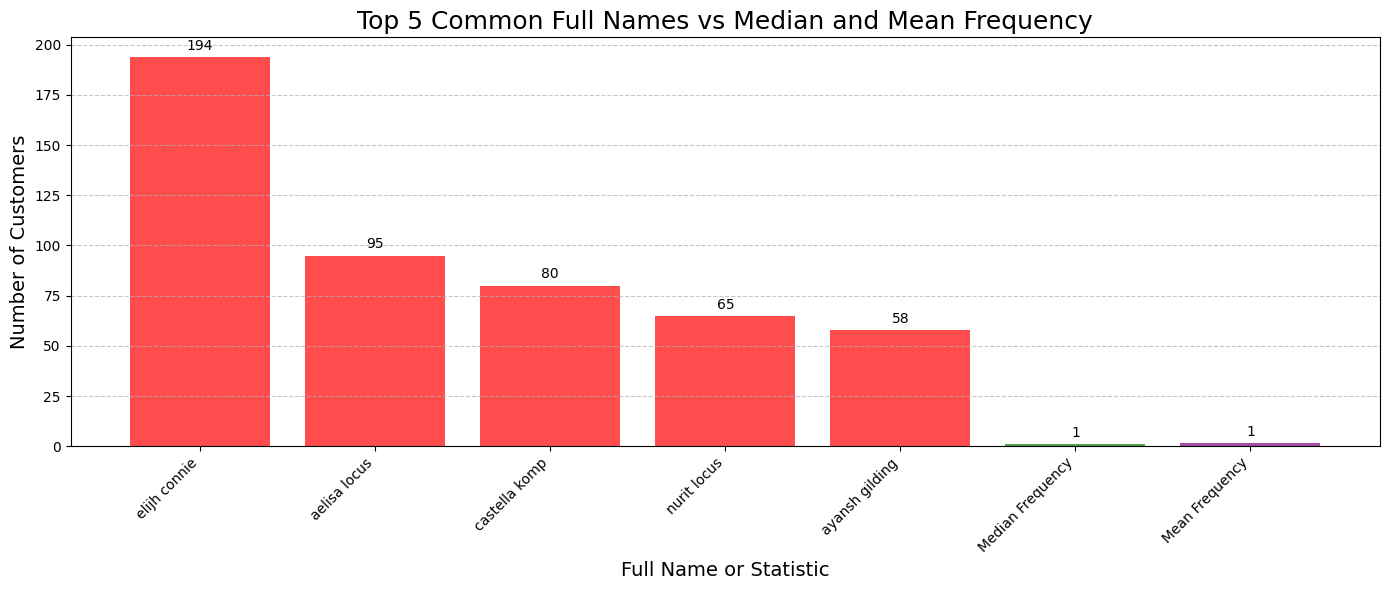

In [ ]:
import matplotlib.pyplot as plt

# --- Step 1: Create full_name column ---
if 'full_name' not in df.columns:
    df['full_name'] = df['firstname'].astype(str) + ' ' + df['lastname'].astype(str)

# --- Step 2: Count full name frequencies ---
full_name_counts = df['full_name'].value_counts()

# --- Step 3: Get Top 5 full names ---
top_5_names = full_name_counts.head(5)

# --- Step 4: Calculate median and mean frequency ---
median_frequency = full_name_counts.median()
mean_frequency = full_name_counts.mean()

# --- Step 5: Prepare combined data for plotting ---
combined_names = top_5_names.copy()
combined_names['Median Frequency'] = median_frequency
combined_names['Mean Frequency'] = mean_frequency

# --- Step 6: Plot ---
plt.figure(figsize=(14, 6))

# Colors: red for names, green for median, purple for mean
colors = ['red'] * 5 + ['green', 'purple']
bars = plt.bar(combined_names.index, combined_names.values, color=colors, alpha=0.7)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=10)

# Titles and labels
plt.title('Top 5 Common Full Names vs Median and Mean Frequency', fontsize=18)
plt.xlabel('Full Name or Statistic', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


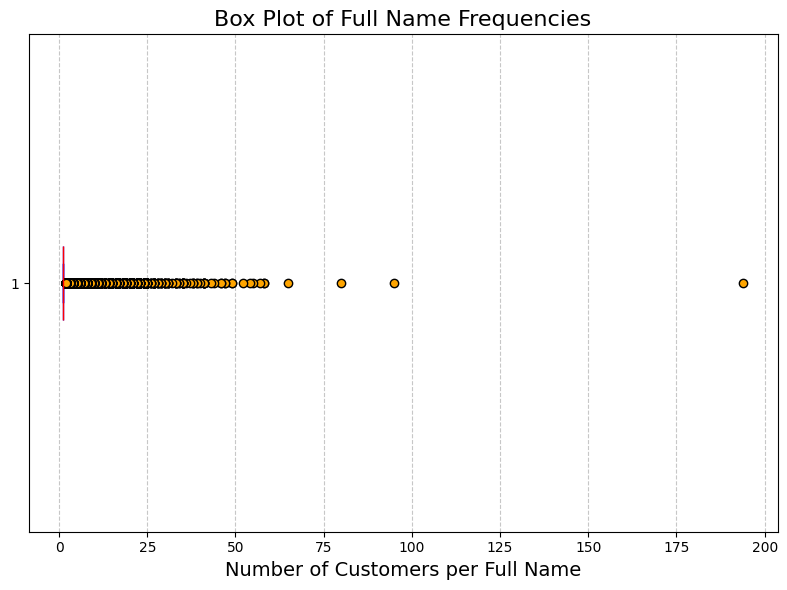

In [ ]:
import matplotlib.pyplot as plt

# --- Step 1: Create full_name column if not already created ---
if 'full_name' not in df.columns:
    df['full_name'] = df['firstname'].astype(str) + ' ' + df['lastname'].astype(str)

# --- Step 2: Count full name frequencies ---
full_name_counts = df['full_name'].value_counts()

# --- Step 3: Plot box plot for frequencies ---
plt.figure(figsize=(8, 6))

plt.boxplot(full_name_counts.values, vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, linestyle='none'))

# Titles and labels
plt.title('Box Plot of Full Name Frequencies', fontsize=16)
plt.xlabel('Number of Customers per Full Name', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Step 1: Count firstname frequency
firstname_counts = df['firstname'].value_counts()

# Step 2: Define suspicious firstnames (top 0.1%)
suspicious_firstnames = firstname_counts[firstname_counts > firstname_counts.quantile(0.999)].index.tolist()

# Step 3: Print how many suspicious names there are
print(f"📊 Number of suspicious firstnames (Top 1% frequent): {len(suspicious_firstnames)}")


📊 Number of suspicious firstnames (Top 1% frequent): 20


**8. High Invoice Frequency per Customer**

In [ ]:
import plotly.graph_objects as go

# --- Step 1: Count invoices per customer ---
invoice_counts = df['customer_no'].value_counts()

# --- Step 2: Detect suspicious customers (top 1% heavy users) ---
threshold = invoice_counts.quantile(0.99)
mask_high_invoice_customer = df['customer_no'].isin(invoice_counts[invoice_counts > threshold].index)

# Mark fraud
df.loc[mask_high_invoice_customer, 'possible_fraud'] += 'High Invoice Frequency per Customer / '
#df['possible_fraud'] = df['possible_fraud'].str.rstrip(' / ')

# --- Step 3: Prepare invoice distribution ---
invoice_distribution = invoice_counts.value_counts().sort_index()

# --- Step 4: Prepare colors ---
colors = ['red' if invoices > threshold else 'blue' for invoices in invoice_distribution.index]

# --- Step 5: Create interactive plot ---
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=invoice_distribution.values,  # Number of customers
    y=invoice_distribution.index,   # Number of invoices
    mode='markers',
    marker=dict(color=colors, size=10),
    text=[f"{y} Invoices → {x} Customers" for x, y in zip(invoice_distribution.values, invoice_distribution.index)],
    hoverinfo='text'
))

# Titles and layout
fig.update_layout(
    title='Interactive Plot: Number of Invoices vs Number of Customers',
    xaxis_title='Number of Customers',
    yaxis_title='Number of Invoices',
    hovermode='closest',
    width=1000,
    height=600
)

fig.show()


**9. Similar Mobile Numbers (Prefix Based)**

Customers sharing very similar mobile number prefixes were identified. This pattern often indicates bulk account creation, SIM farms, or automated fake account generation, especially during periods of weak system controls. These cases have been flagged under 'Similar Mobile Numbers' for further review.

In [ ]:
# Detect groups of mobile numbers with same starting digits
df['mobile_prefix'] = df['mobile'].astype(str).str[:6]

common_mobile_prefixes = df['mobile_prefix'].value_counts()
popular_prefixes = common_mobile_prefixes[common_mobile_prefixes > common_mobile_prefixes.quantile(0.99)].index

mask_mobile_prefix = df['mobile_prefix'].isin(popular_prefixes)

df.loc[mask_mobile_prefix & ~df['possible_fraud'].str.contains('Similar Mobile Numbers', na=False), 'possible_fraud'] += 'Similar Mobile Numbers / '

print("\n📲 Top 5 Similar Mobile Numbers Cases:\n")
print(df[mask_mobile_prefix][['customer_no', 'mobile']].head())



📲 Top 5 Similar Mobile Numbers Cases:

                                         customer_no     mobile
2  7ba14e8e3f439fa5cc1135f8caafbd2ab346dd18206c3f...  451007756
3  7ba14e8e3f439fa5cc1135f8caafbd2ab346dd18206c3f...  451007756
4  7ba14e8e3f439fa5cc1135f8caafbd2ab346dd18206c3f...  451007756
5  7ba14e8e3f439fa5cc1135f8caafbd2ab346dd18206c3f...  451007756
6  7ba14e8e3f439fa5cc1135f8caafbd2ab346dd18206c3f...  451007756


**10. Suspicious City Usage**

An unusually high concentration of invoices originated from a few specific cities.
Such geographic clustering often indicates coordinated fraudulent activity, the use of fake addresses, or exploitation of known shipping weaknesses.
These cases have been flagged under 'Suspicious City Usage' for further investigation.

In [ ]:
# Detect cities with an unusually high number of invoices
city_counts = df['city'].value_counts()
suspicious_cities = city_counts[city_counts > city_counts.quantile(0.99)].index

mask_suspicious_city = df['city'].isin(suspicious_cities)

df.loc[mask_suspicious_city & ~df['possible_fraud'].str.contains('Suspicious City Usage', na=False), 'possible_fraud'] += 'Suspicious City Usage / '

print("\n🏙️ Top 5 Suspicious City Usage Cases:\n")
print(df[mask_suspicious_city][['customer_no', 'city']].drop_duplicates().head())



🏙️ Top 5 Suspicious City Usage Cases:

                                          customer_no       city
7   69cd170c626cdc8ad22ea739818a4278937aa7a306d0f2...       Lund
38  3d10aff6e235a299174c0568c43f8ca3ab5b5ccd319806...  Stockholm
48  70cabcffc17011c4e70a8215848031e08a0e39cff75a32...   Göteborg
57  d1608e48696bd583c0d2e5a41fe48c2af504fcab8b2712...    Uppsala
68  2af44a7a2fc44e864ad254c1c64c5faef159f066cbf168...  Stockholm


In [ ]:
# --- Show all fraud cases with 5 or more different fraud types ---

# Step 1: Select rows where 'possible_fraud' is not empty
possible_frauds = df[df['possible_fraud'] != '']

# Step 2: Count how many different fraud labels each case has
# (fraud types are separated by " / ")
possible_frauds['fraud_count'] = possible_frauds['possible_fraud'].apply(lambda x: len(x.split(' / ')))

# Step 3: Filter for rows with 3 or more fraud reasons
serious_fraud_cases = possible_frauds[possible_frauds['fraud_count'] >= 5]

# Step 4: Ensure pandas shows the full column contents
pd.set_option('display.max_colwidth', None)

# Step 5: Print top 20 serious fraud cases (with full possible_fraud)
print("\n🚨 Top Cases with 3 or More Fraud Types Detected:\n")
print(serious_fraud_cases[['firstname', 'lastname', 'possible_fraud']].head(20))

# Step 6: Print total number of such cases
print(f"\n📊 Total number of cases with 3 or more fraud types: {len(serious_fraud_cases)}")



🚨 Top Cases with 3 or More Fraud Types Detected:

   firstname     lastname  \
12     silve    felderman   
13     silve    felderman   
14     silve    felderman   
15     silve    felderman   
17  filoteia        scheu   
32    mayari        nezat   
35      tatu         uren   
51  sahajaha  zubizarreta   
59    mattew       khanna   
60    mattew       khanna   
61    mattew       khanna   
62    mattew       khanna   
63    mattew       khanna   
68    kwamin        graap   
69   suhayma        garbe   
70   suhayma        garbe   
71   suhayma        garbe   
72   suhayma        garbe   
75    hyqmet    osterback   
78     eroll      horesco   

                                                                                                                                                                                possible_fraud  
12                                                          Same Mobile Different Identity / Same Address Different Identity / High Invoice Freque

<ipython-input-23-b2c0eca8bbd0>:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# 3. Trend correlation or fraud pattern matching.

**If the spike in period_start (many invoices at once)**

also matches spikes in:

Suspicious cities,

Suspicious mobile prefixes,

Suspicious names,

Stopped reminders,

Other fraud markers.

In [ ]:
# Group fraud counts per day
fraud_trends = df.groupby('period_start')['possible_fraud'].apply(lambda x: ' / '.join(x)).reset_index()

In [ ]:
# For each fraud type, create trend indicators (how many times they happen per day)
# Create indicators for each type of fraud
fraud_trends['Emergency_Fraud_Period'] = fraud_trends['possible_fraud'].str.count('Emergency Fraud Period')
fraud_trends['Suspicious_City_Usage'] = fraud_trends['possible_fraud'].str.count('Suspicious City Usage')
fraud_trends['Similar_Mobile_Numbers'] = fraud_trends['possible_fraud'].str.count('Similar Mobile Numbers')
fraud_trends['Suspicious_Born_Year'] = fraud_trends['possible_fraud'].str.count('Suspicious Born Year')
fraud_trends['Reminder_Stopped_High_Amount'] = fraud_trends['possible_fraud'].str.count('Reminder Stopped with High Amount')
fraud_trends['Common_Firstname_or_Lastname'] = fraud_trends['possible_fraud'].str.count('Common Firstname or Lastname')


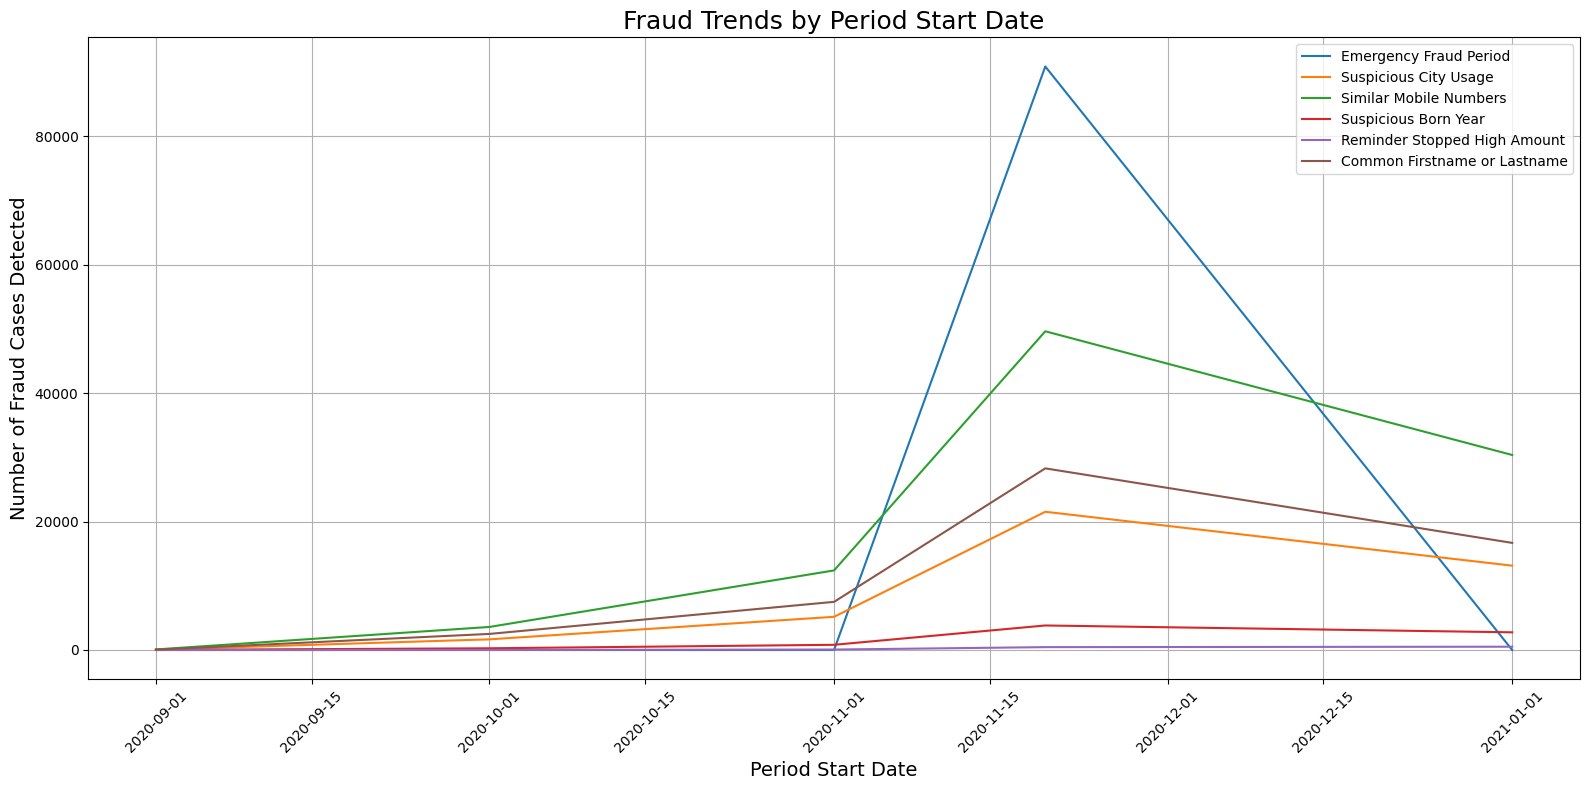

In [ ]:
# Plot the trends over time to compare them

# Plot all major fraud types together
plt.figure(figsize=(16,8))

plt.plot(fraud_trends['period_start'], fraud_trends['Emergency_Fraud_Period'], label='Emergency Fraud Period')
plt.plot(fraud_trends['period_start'], fraud_trends['Suspicious_City_Usage'], label='Suspicious City Usage')
plt.plot(fraud_trends['period_start'], fraud_trends['Similar_Mobile_Numbers'], label='Similar Mobile Numbers')
plt.plot(fraud_trends['period_start'], fraud_trends['Suspicious_Born_Year'], label='Suspicious Born Year')
plt.plot(fraud_trends['period_start'], fraud_trends['Reminder_Stopped_High_Amount'], label='Reminder Stopped High Amount')
plt.plot(fraud_trends['period_start'], fraud_trends['Common_Firstname_or_Lastname'], label='Common Firstname or Lastname')

plt.title('Fraud Trends by Period Start Date', fontsize=18)
plt.xlabel('Period Start Date', fontsize=14)
plt.ylabel('Number of Fraud Cases Detected', fontsize=14)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


**Interpretation:**

Analysis revealed that all major detected fraud behaviors (e.g., fake identities, abnormal purchase volumes, suspicious addresses) peaked around 20th November — a non-standard invoice start date.
This strongly indicates coordinated exploitation following the system's risk validation outage.
The 20th November marks a clear start of the emergency fraud period.

# More Visualisations:

In [ ]:
# Save Data:

#Clean Final possible_fraud Column
# Remove any trailing slashes
df['possible_fraud'] = df['possible_fraud'].str.rstrip(' / ')


# Save the DataFrame to a CSV file
df.to_csv('processed_invoices_with_possible_fraud.csv', index=False)

# Using Google Colab: download it
from google.colab import files
#files.download('processed_invoices_with_possible_fraud.csv')


In [ ]:
import plotly.graph_objects as go

# --- Step 1: Split and count fraud types ---
fraud_types = df['possible_fraud'].dropna().str.split(' / ').explode()
fraud_type_counts = fraud_types.value_counts().sort_values(ascending=False)

# --- Step 2: Create the interactive bar plot ---
fig = go.Figure(data=[
    go.Bar(
        x=fraud_type_counts.index,
        y=fraud_type_counts.values,
        text=fraud_type_counts.values,
        textposition='auto',  # Show the counts directly on bars
        marker_color='red',
        hoverinfo='x+y',  # Show fraud type and count on hover
    )
])

# --- Step 3: Layout settings ---
fig.update_layout(
    title='Distribution of Predicted Fraud Types',
    xaxis_title='Fraud Type',
    yaxis_title='Number of Cases',
    xaxis_tickangle=-45,
    width=1000,
    height=600,
    template='simple_white',
)

# Show plot
fig.show()


# Dashboard by streamlit

In [ ]:
!pip install streamlit pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.3 MB/s eta 0:00:00


In [ ]:
with open('app.py', 'w') as f:
   f.write('''
import streamlit as st
import pandas as pd

# --- Expand the page layout ---
st.set_page_config(page_title="🚨 Fraud Detection Dashboard", layout="wide", initial_sidebar_state="expanded")

# --- Load your dataset ---
df = pd.read_csv('processed_invoices_with_possible_fraud.csv')

# --- Extract all fraud types dynamically ---
fraud_types_set = set()
df['possible_fraud'].dropna().str.split(' / ').apply(fraud_types_set.update)
fraud_types = sorted(fraud_types_set)

# --- Dashboard Title ---
st.title('🚨 Fraud Detection Dashboard')

# --- Sidebar: Fraud Type Selector ---
st.sidebar.header('Select Fraud Types')
selected_frauds = st.sidebar.multiselect('Fraud Types:', fraud_types)

# --- Main Panel ---
if selected_frauds:
    def calculate_fraud_score(possible_fraud):
        if pd.isnull(possible_fraud):
            return 0
        fraud_list = [f.strip() for f in possible_fraud.split(' / ')]
        return sum(fraud in fraud_list for fraud in selected_frauds)

    df['fraud_score'] = df['possible_fraud'].apply(calculate_fraud_score)

    filtered_df = df[df['fraud_score'] > 0]

    if not filtered_df.empty:
        sorted_filtered_df = filtered_df.sort_values(by='fraud_score', ascending=False)

        st.subheader(f"🔎 {len(sorted_filtered_df)} Customers Matching Selected Frauds")

        # --- Show filtered table (sorted by fraud_score)
        st.dataframe(
            sorted_filtered_df[['invoice_no', 'possible_fraud', 'fraud_score']].reset_index(drop=True),
            use_container_width=True
        )

        # --- Create pivot-style fraud matrix ---
        st.subheader("📋 Customer Fraud Type Matrix")

        expanded_rows = []
        for idx, row in filtered_df.iterrows():
            fraud_list = [f.strip() for f in str(row['possible_fraud']).split(' / ') if f.strip()]
            for fraud in fraud_list:
                expanded_rows.append({'invoice_no': row['invoice_no'], 'fraud_type': fraud})

        exploded_df = pd.DataFrame(expanded_rows)

        pivot_df = exploded_df.pivot_table(index='invoice_no', columns='fraud_type', aggfunc=lambda x: '✅', fill_value='')

        # Keep only selected frauds in pivot columns
        pivot_df = pivot_df.reindex(columns=selected_frauds)

        # 🧠 NEW: Reindex rows to match order in sorted_filtered_df
        pivot_df = pivot_df.loc[sorted_filtered_df['invoice_no']]

        # --- Show matrix table (same order as first table)
        st.dataframe(pivot_df.reset_index(), use_container_width=True)

    else:
        st.warning("⚠️ No customers match the selected fraud types. Please try selecting different frauds.")

else:
    st.info("👈 Please select one or more fraud types to start analysis.")
''')


In [ ]:
import threading
import os
import time

def run():
    os.system('streamlit run app.py')

thread = threading.Thread(target=run)
thread.start()

time.sleep(5)  # Give Streamlit time to boot


In [ ]:
!ngrok config add-authtoken 2wPkVzNfuRmMAa8hfM9DypwcSOL_6QJZEr6cKKRYV9fq4efjk


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

# Connect to Streamlit app
public_url = ngrok.connect(addr="8501", proto="http")
print(f"🚀 Your app is live at: {public_url}")


🚀 Your app is live at: NgrokTunnel: "https://d4ea-34-16-17-35.ngrok-free.app" -> "http://localhost:8501"
